# visualize data sets 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import dates as mdates

import os,sys

from importlib import reload    

sys.path.append(os.path.abspath('..'))

import src.utils.L0_dataloaders as dl0

In [2]:
from src.utils.plot_utils import set_mpl_style
set_mpl_style(theme='light')

In [3]:
import src.utils.plot_utils as pu

In [4]:
reload(pu)
pu.set_mpl_style(theme='white')

# new L0 df format

In [5]:
# read pkl file
fname =  f'../data/l0_datasets/Pandora117s1_Rome-SAP_20240701_20240715.pkl'

fname =  f'../data/l0_datasets/Pandora117s1_Rome-SAP_20240701_20241231.pkl'

#fname =  f'../data/l0_datasets/Pandora117s1_Rome-SAP_20240101_20241231.pkl'



df_l0_all = pd.read_pickle(fname)

df_l0_all.head()

,routine_code,integration_time,routine_count,repetition_count,filterwheel_pos1,filterwheel_pos2,aux_spec_temp,head_sens_temp,elec_temp1,data,date
time,,,,,,,,,,,
2024-07-01 09:35:45.900,SQ,4.19,3,1,2,2,20.77,40.39,23.32,"[616.4976076555024, 613.0518341307815, 611.845...",20240701
2024-07-01 09:35:52.000,SQ,4.19,3,2,2,2,20.77,40.39,23.32,"[616.133971291866, 612.3301435406698, 611.5502...",20240701
2024-07-01 09:35:58.300,SQ,4.19,3,3,2,2,20.77,40.39,23.32,"[616.3094098883572, 612.1523125996811, 612.138...",20240701
2024-07-01 09:36:04.400,SQ,4.19,3,4,2,2,20.77,40.39,23.32,"[616.2288676236045, 612.1810207336523, 611.728...",20240701
2024-07-01 09:36:10.600,SQ,4.19,3,5,2,2,20.77,40.39,23.32,"[617.7392344497607, 613.9832535885167, 612.694...",20240701


In [6]:
# set filterwheel_pos1 and filterwheel_pos2 to int
df_l0_all['filterwheel_pos1'] = df_l0_all['filterwheel_pos1'].astype(int)
df_l0_all['filterwheel_pos2'] = df_l0_all['filterwheel_pos2'].astype(int)

In [7]:
df_l0_all[(df_l0_all['filterwheel_pos1'] == 2) & (df_l0_all['filterwheel_pos2'] == 2)]

,routine_code,integration_time,routine_count,repetition_count,filterwheel_pos1,filterwheel_pos2,aux_spec_temp,head_sens_temp,elec_temp1,data,date
time,,,,,,,,,,,
2024-07-01 09:35:45.900,SQ,4.19,3,1,2,2,20.77,40.39,23.32,"[616.4976076555024, 613.0518341307815, 611.845...",20240701
2024-07-01 09:35:52.000,SQ,4.19,3,2,2,2,20.77,40.39,23.32,"[616.133971291866, 612.3301435406698, 611.5502...",20240701
2024-07-01 09:35:58.300,SQ,4.19,3,3,2,2,20.77,40.39,23.32,"[616.3094098883572, 612.1523125996811, 612.138...",20240701
2024-07-01 09:36:04.400,SQ,4.19,3,4,2,2,20.77,40.39,23.32,"[616.2288676236045, 612.1810207336523, 611.728...",20240701
2024-07-01 09:36:10.600,SQ,4.19,3,5,2,2,20.77,40.39,23.32,"[617.7392344497607, 613.9832535885167, 612.694...",20240701
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 11:54:04.400,SQ,4.15,168,7,2,2,31.58,23.62,20.77,"[568.0766798418972, 564.9501976284585, 563.657...",20241231
2024-12-31 11:54:10.500,SQ,4.15,168,8,2,2,31.58,23.59,20.77,"[582.4150197628459, 578.1691699604743, 576.396...",20241231
2024-12-31 11:54:16.600,SQ,4.15,168,9,2,2,31.58,23.59,20.77,"[578.0956521739131, 575.6474308300395, 573.098...",20241231


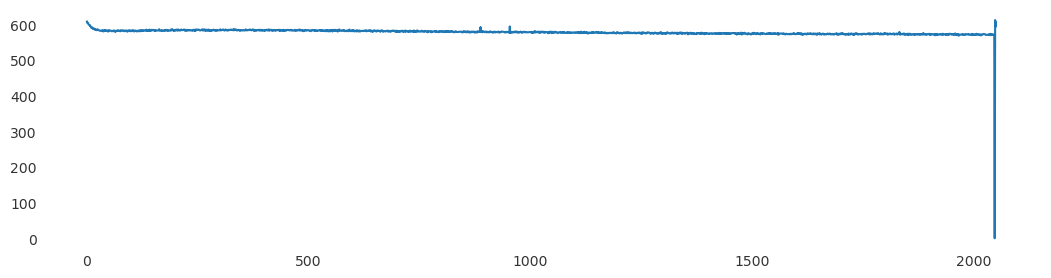

In [8]:
# plot 'Mean over all cycles 2043' but only filterwhee 1 and 2 combination of 2 and 2
# 
ax = plt.figure(figsize=(10,6)).add_axes([0,0,1,.4])
ax.plot(df_l0_all[(df_l0_all['filterwheel_pos1'] == 6) & (df_l0_all['filterwheel_pos2'] == 3)]['data'][5])


In [9]:
reload(dl0) 

fw_comb_closed = {"fw1": 6, "fw2": 3} # filterwheel positions for closed position

df_l0_all_corrected = dl0.apply_dark_correction(df_l0_all,fw_comb_closed)

df_l0_all_corrected.head(20)

# filter out dark measurements
df_l0_all_corrected_filtered = dl0.filter_dark_measurements(df_l0_all_corrected,fw_comb_closed)

In [10]:
df_l0_all_corrected_filtered.head()

,routine_code,integration_time,routine_count,repetition_count,filterwheel_pos1,filterwheel_pos2,aux_spec_temp,head_sens_temp,elec_temp1,data,date
time,,,,,,,,,,,
2024-07-01 09:35:45.900,SQ,4.19,3,1,2,2,20.77,40.39,23.32,"[8.819496067519594, 9.210632414043289, 9.25302...",20240701
2024-07-01 09:35:52.000,SQ,4.19,3,2,2,2,20.77,40.39,23.32,"[8.45585970388322, 8.488941823931668, 8.957964...",20240701
2024-07-01 09:35:58.300,SQ,4.19,3,3,2,2,20.77,40.39,23.32,"[8.631298300374397, 8.311110882942899, 9.54648...",20240701
2024-07-01 09:36:04.400,SQ,4.19,3,4,2,2,20.77,40.39,23.32,"[8.550756035621703, 8.339819016914134, 9.13579...",20240701
2024-07-01 09:36:10.600,SQ,4.19,3,5,2,2,20.77,40.39,23.32,"[10.061122861777903, 10.142051871778563, 10.10...",20240701


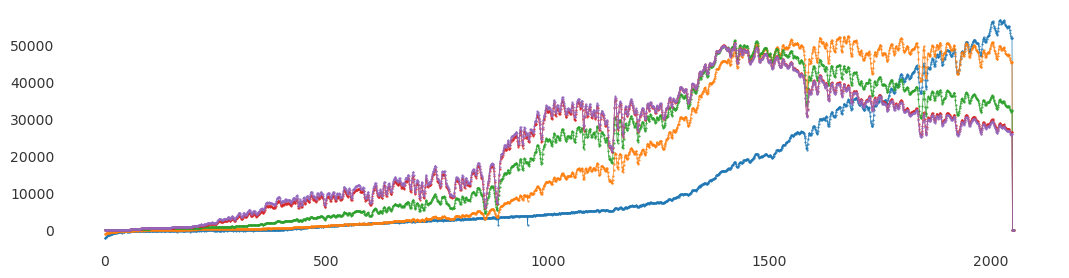

In [11]:
# filter for 12.7.2024
ind = df_l0_all_corrected_filtered.index.date == pd.Timestamp('2024-07-12').date()

ax = plt.figure(figsize=(10,6)).add_axes([0,0,1,.4])

ax.plot(df_l0_all_corrected_filtered[ind]['data'][0],'.-',lw=.5,ms=1)
ax.plot(df_l0_all_corrected_filtered[ind]['data'][10],'.-',lw=.5,ms=1)
ax.plot(df_l0_all_corrected_filtered[ind]['data'][50],'.-',lw=.5,ms=1)
ax.plot(df_l0_all_corrected_filtered[ind]['data'][180],'.-',lw=.5,ms=1)
ax.plot(df_l0_all_corrected_filtered[ind]['data'][280],'.-',lw=.5,ms=1)

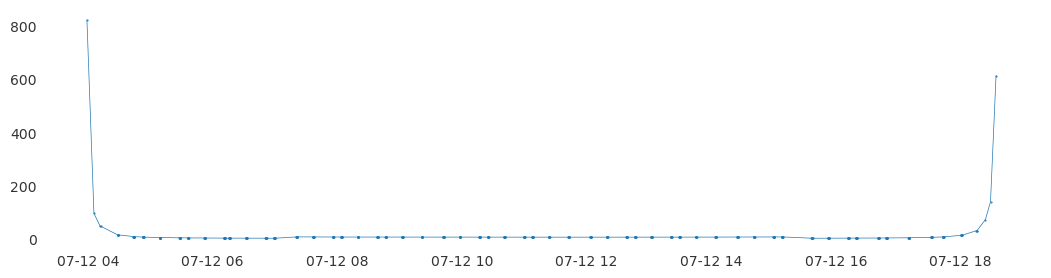

In [12]:
# plot integration time
ax = plt.figure(figsize=(10,6)).add_axes([0,0,1,.4])
ax.plot(df_l0_all_corrected_filtered[ind]['integration_time'],'.-',lw=.5,ms=1)

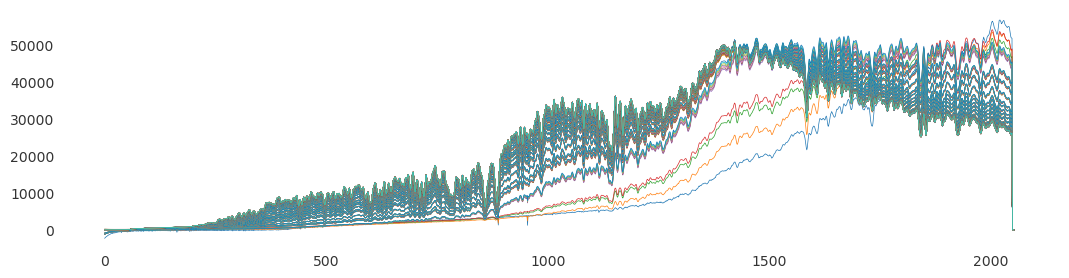

In [13]:
ax = plt.figure(figsize=(10,6)).add_axes([0,0,1,.4])

for spectrum in df_l0_all_corrected_filtered[ind]['data'][0:300]:
    ax.plot(spectrum,'.-',lw=.5,ms=0)

In [14]:
df_l0_all_corrected_filtered['data'].values

array([list([8.819496067519594, 9.210632414043289, 9.253020377709731, 10.864067601700299, 10.746339610243012, 10.860087205919626, 11.29281064541965, 8.868102757870133, 11.155721433900794, 11.5942631647398, 11.708075788378551, 13.171434243040267, 10.873164671334962, 12.884445311483887, 12.458522427801881, 13.779329322134913, 14.992100813876277, 15.224257483349334, 14.352838299416135, 15.724637383548611, 15.000109520778096, 15.517735521010877, 16.57145204016672, 16.689912451828036, 17.70335954986956, 17.547347201401863, 18.0847348570411, 18.09564586456395, 17.490800254635815, 21.94227912739325, 20.74573724596314, 20.412308081948936, 22.527024252007323, 21.28477113579902, 24.596669199334656, 22.41664442025865, 23.238050256347037, 24.674261248126186, 24.086524837258935, 26.00151960079677, 25.197127133088316, 27.955958957088342, 26.471582780595668, 30.58306124265016, 28.693465032068957, 31.405007837580683, 32.76323661279616, 32.074333805641686, 32.747794183077644, 35.10675195597264, 36.9154

In [15]:
#ind = df_l0_all_corrected_filtered.index.date == pd.Timestamp('2024-07-12').date()
#df_l0_all_corrected_filtered_norm = normalize_by_integration_time(df_l0_all_corrected_filtered[ind])

df_l0_all_corrected_filtered_norm = dl0.normalize_by_integration_time(df_l0_all_corrected_filtered)

In [16]:
# save as pkl in data folder as "df_l0_all_corrected_filtered_norm.pkl"
df_l0_all_corrected_filtered_norm.to_pickle('../data/l0_datasets/Pandora117s1_Rome-SAP_20240701_20241231.pkl')
#df_l0_all_corrected_filtered_norm.to_pickle('../data/l0_datasets/df_l0_all_corrected_filtered_norm.pkl')

In [5]:
# read pkl file
df_l0_all_corrected_filtered_norm = pd.read_pickle('../data/l0_datasets/df_l0_all_corrected_filtered_norm.pkl')
df_l0_all_corrected_filtered_norm.head()

: 

: 

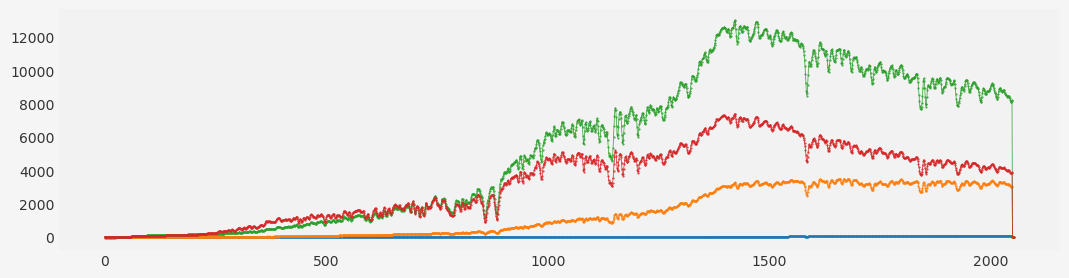

In [112]:
ax = plt.figure(figsize=(10,6)).add_axes([0,0,1,.4])
ax.plot(df_l0_all_corrected_filtered_norm['data'][0],'.-',lw=.5,ms=1)
ax.plot(df_l0_all_corrected_filtered_norm['data'][10],'.-',lw=.5,ms=1)
ax.plot(df_l0_all_corrected_filtered_norm['data'][50],'.-',lw=.5,ms=1)
ax.plot(df_l0_all_corrected_filtered_norm['data'][180],'.-',lw=.5,ms=1)

In [346]:
reload(pu)

<module 'src.utils.plot_utils' from 'c:\\Users\\AK\\LuftBlick\\OneSun\\src\\utils\\plot_utils.py'>

In [9]:
#import mdates 
from matplotlib import dates as mdates

def plot_pixel_timeseries(df,ncols=5):
    """Plot time series for specific pixels across days."""
    fig = plt.figure(figsize=(20,12))
    #ncols = 5
    w, h = .2, .15
    dw, dh = .02, .05
    

    # Convert datetime column to pandas datetime if it's not already
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df['datetime'])
    
  # Get cloudscreen mask
    clean_mask = dl0.cloudscreen_df(df, time_window='360s', pixel_idx=1000, lim=5e-2)
      

    # Get unique dates
    dts = np.unique(df.index.date)
    
    # Selected pixels to plot
    pixels = [2000, 1500, 1000, 500]
    colors = [(.1,.1,.3), (.1,.3,.8), (.2,.7,.9), (.7,.5,.7)]
    
    k = 0
    for day_value in dts:
        day_date = pd.Timestamp(day_value)
        day_df = df[df.index.date == day_value]
        day_mask = clean_mask[df.index.date == day_value]

        
        r, c = divmod(k, ncols)
        ax = fig.add_axes([c*(w+dw), 1-(r+1)*(h+dh), w, h])
        
        # plot filterwheel_pos2
        #ax.plot(day_df['filterwheel_pos1'].astype(int) * 1e4 ,'.',ms=1)
        #ax.plot(day_df['filterwheel_pos2'].astype(int) * 1e4 ,'.',ms=1)
        # Plot data for each selected pixel
        ms = 4
        for pixel, color in zip(pixels, colors):
            pixel_values = [spectrum[pixel] for spectrum in day_df['data']]

        #    # Extract the specified pixel from each spectrum
        #    pixel_values = [spectrum[pixel] for spectrum in day_df['data']]
        #    
        #    ax.plot(day_df.index, pixel_values, '.-', c=color, ms=ms, lw=.1)
        
            # Plot cloudy data
            cloudy_times = day_df.index[~day_mask]
            cloudy_values = [pixel_values[i] for i in range(len(pixel_values)) 
                            if day_df.index[i] in cloudy_times]
            if cloudy_values:
                ax.plot(cloudy_times, cloudy_values, '.-', c=(.7,.7,.7), 
                        alpha=0.5, ms=ms-1, lw=.1)
                
            # Plot clean data
            clean_times = day_df.index[day_mask]
            clean_values = [pixel_values[i] for i in range(len(pixel_values)) 
                            if day_df.index[i] in clean_times]
            if clean_values:
                ax.plot(clean_times, clean_values, '.-', c=color, 
                        alpha=1, ms=ms, lw=.1)
      
        # Set time limits and format
        start_time = day_date + pd.Timedelta(hours=2)
        end_time = day_date + pd.Timedelta(hours=21)
        ax.set_xlim(start_time, end_time)
        
        # Set x-ticks
        tick_hours = [6, 9, 12, 15, 18, 21]
        tick_times = [day_date + pd.Timedelta(hours=h) for h in tick_hours]
        ax.set_xticks(tick_times)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H'))
        
        ax.set_ylim(-1e3,5e4)

        # Add title
        ax.annotate(str(day_value), xy=(0,1.05), xycoords='axes fraction', 
                   ha='left', fontsize=12)
        
        ax.grid(True)
        k += 1
    
    #plt.show()
    return fig

def plot_all_spectra(df):
    """Plot all spectra from the data column overlaid."""
    ax = plt.figure(figsize=(10,6)).add_axes([0,0,1,.4])
    
    for spectrum in df['data']:
        if isinstance(spectrum, str):
            spectrum = eval(spectrum)  # Convert string to list if needed
        ax.plot(spectrum,'.-',lw = .1,ms=.1 ,alpha=0.1, color='blue')
    
    ax.set_xlabel('Pixel')
    ax.set_ylabel('Intensity')
    
    return ax

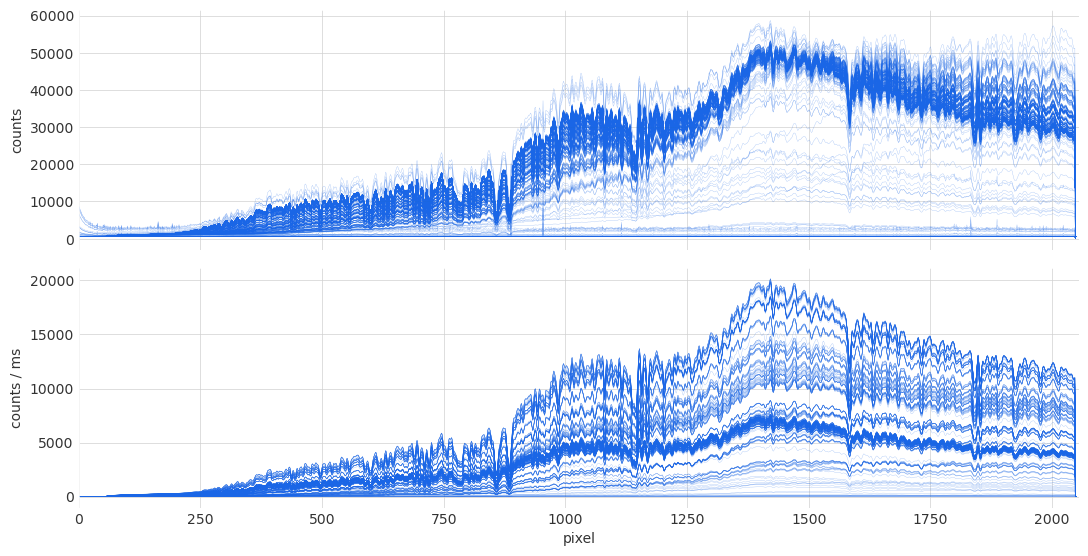

In [49]:
mask = (df_l0_all_corrected_filtered.index >= '2024-07-01') & (df_l0_all_corrected_filtered.index <= '2024-07-2')

#df = df_l0_all_corrected_filtered[mask].copy()
df = df_l0_all[df_l0_all['date']=="20240702"].copy()

fig = plt.figure(figsize=(10,6))

ax= fig.add_axes([0,.43,1,.4])
    
for spectrum in df['data']:
    ax.plot(spectrum,'.-',lw = .2,ms=0 ,alpha=.5, color=(.1,.4,.9))

ax.set_xlim(0, 2055)
#ax.set_xlabel('pixel')
ax.set_xticklabels([])

ax.set_ylabel('counts')

ax.grid(True)

df = df_l0_all_corrected_filtered_norm[df_l0_all_corrected_filtered_norm['date']=="20240702"].copy()

ax2 = fig.add_axes([0,0,1,.4])
    
for spectrum in df['data']:
    ax2.plot(spectrum,'.-',lw = .2,ms=0 ,alpha=.5, color=(.1,.4,.9))

ax2.set_xlim(0, 2055)
ax2.set_xlabel('pixel')
ax2.set_ylabel('counts / ms')

ax2.grid(True)

fig.savefig('../plots/spectra_20240702.png',bbox_inches='tight',dpi=600)

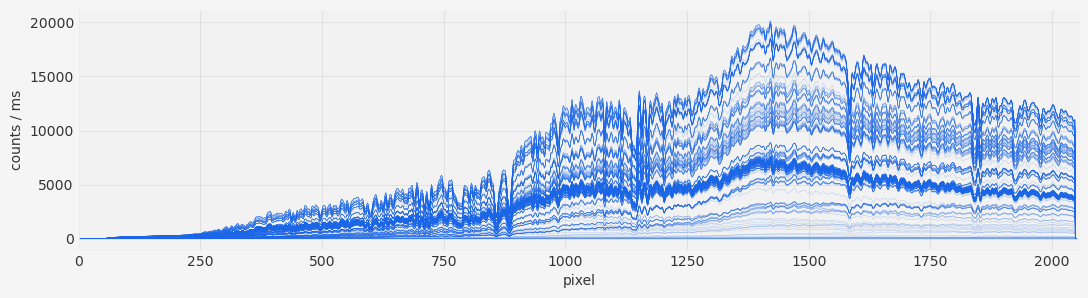

In [38]:
#mask = (df_l0_all_corrected_filtered_norm.index >= '2024-07-02') & (df_l0_all_corrected_filtered_norm.index <= '2024-07-3')
#df = df_l0_all_corrected_filtered_norm[mask].copy()
df = df_l0_all_corrected_filtered_norm[df_l0_all_corrected_filtered_norm['date']=="20240702"].copy()

ax = plt.figure(figsize=(10,6)).add_axes([0,0,1,.4])
    
for spectrum in df['data']:
    ax.plot(spectrum,'.-',lw = .2,ms=0 ,alpha=.5, color=(.1,.4,.9))

ax.set_xlim(0, 2055)
ax.set_xlabel('pixel')
ax.set_ylabel('counts / ms')

ax.grid(True)

In [17]:
df.iloc[0].date,df.iloc[-1].date

('20240701', '20240701')

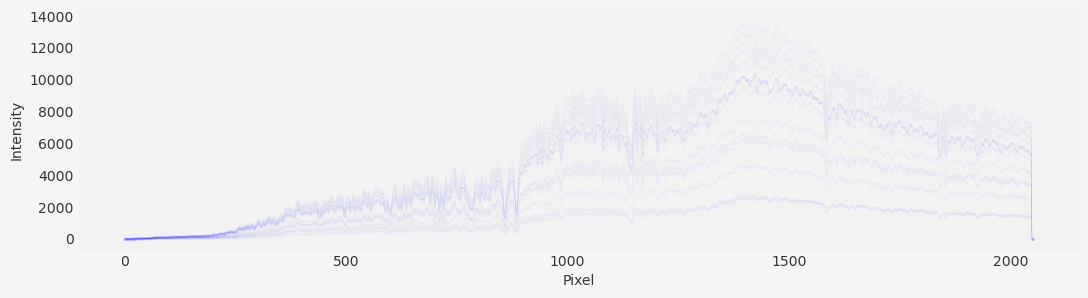

In [10]:
mask = (df_l0_all_corrected_filtered_norm.index >= '2024-07-01') & (df_l0_all_corrected_filtered_norm.index <= '2024-07-2')
ax = plot_all_spectra(df_l0_all_corrected_filtered_norm[mask].iloc[::10])

#save figure in plots folder
#plt.savefig('../plots/all_spectra.png',bbox_inches='tight',dpi=300)

In [ ]:
ax = plot_all_spectra(df_l0_all_corrected_filtered.iloc[::20])


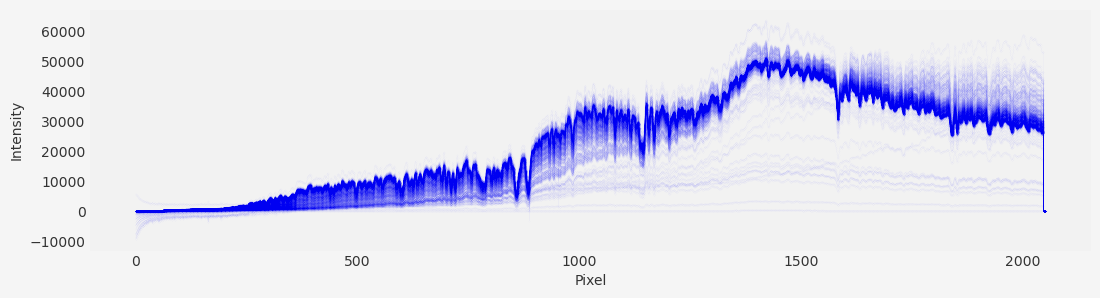

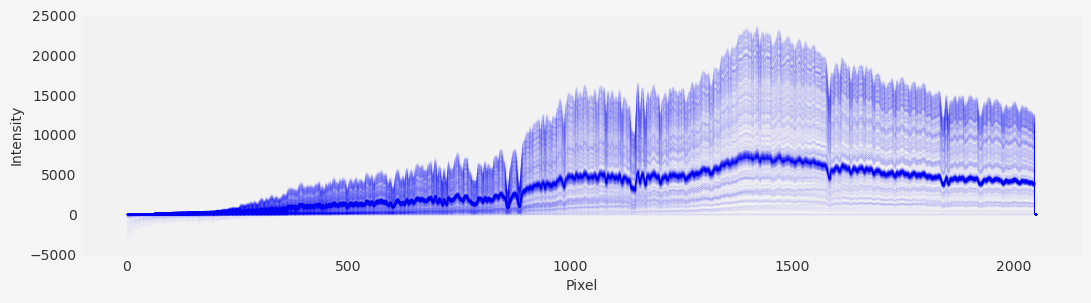

In [221]:
ax = plot_all_spectra(df_l0_all_corrected_filtered.iloc[::20])
ax = plot_all_spectra(df_l0_all_corrected_filtered_norm.iloc[::20])

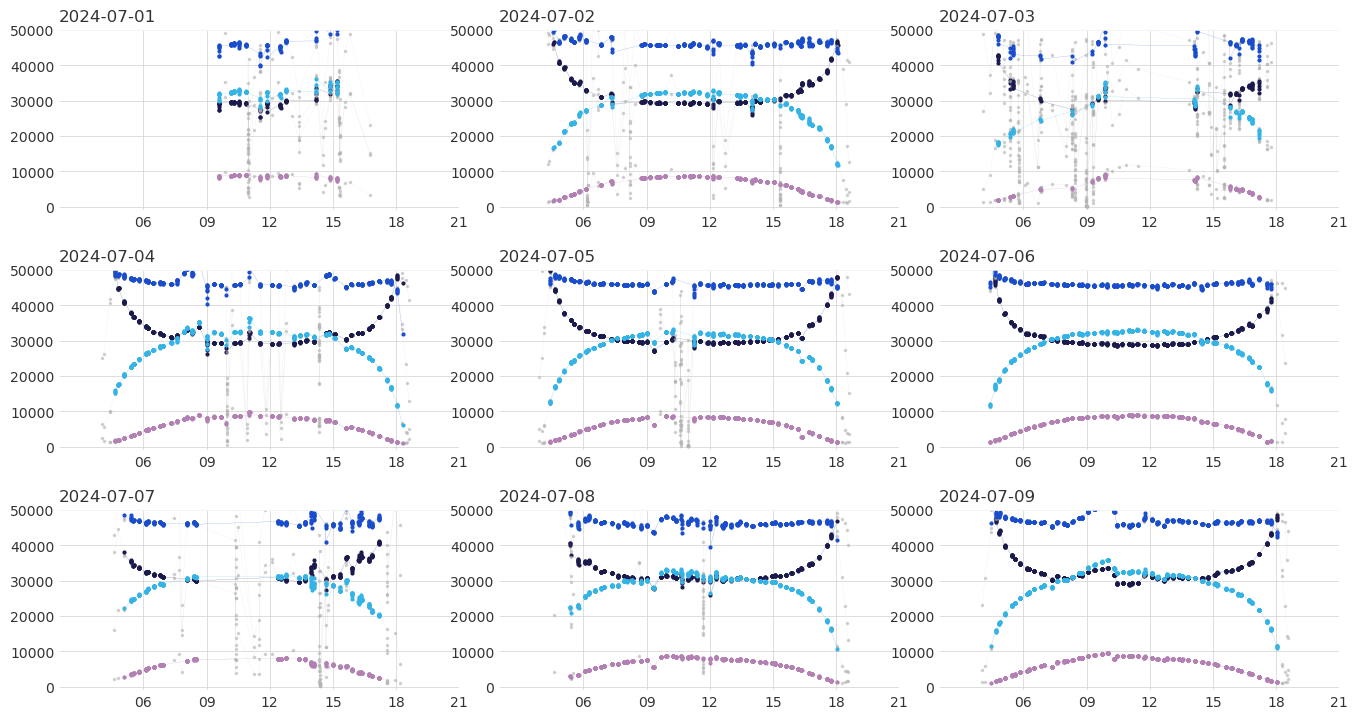

In [54]:
# plot first 2 weeks in July 2024

mask = (df_l0_all_corrected_filtered.index >= '2024-07-01') & (df_l0_all_corrected_filtered.index <= '2024-07-10')
fig = plot_pixel_timeseries(df_l0_all_corrected_filtered[mask],ncols=3)

fig.savefig('../plots/pixel_timeseries_notnorm.png',bbox_inches='tight',dpi=300)

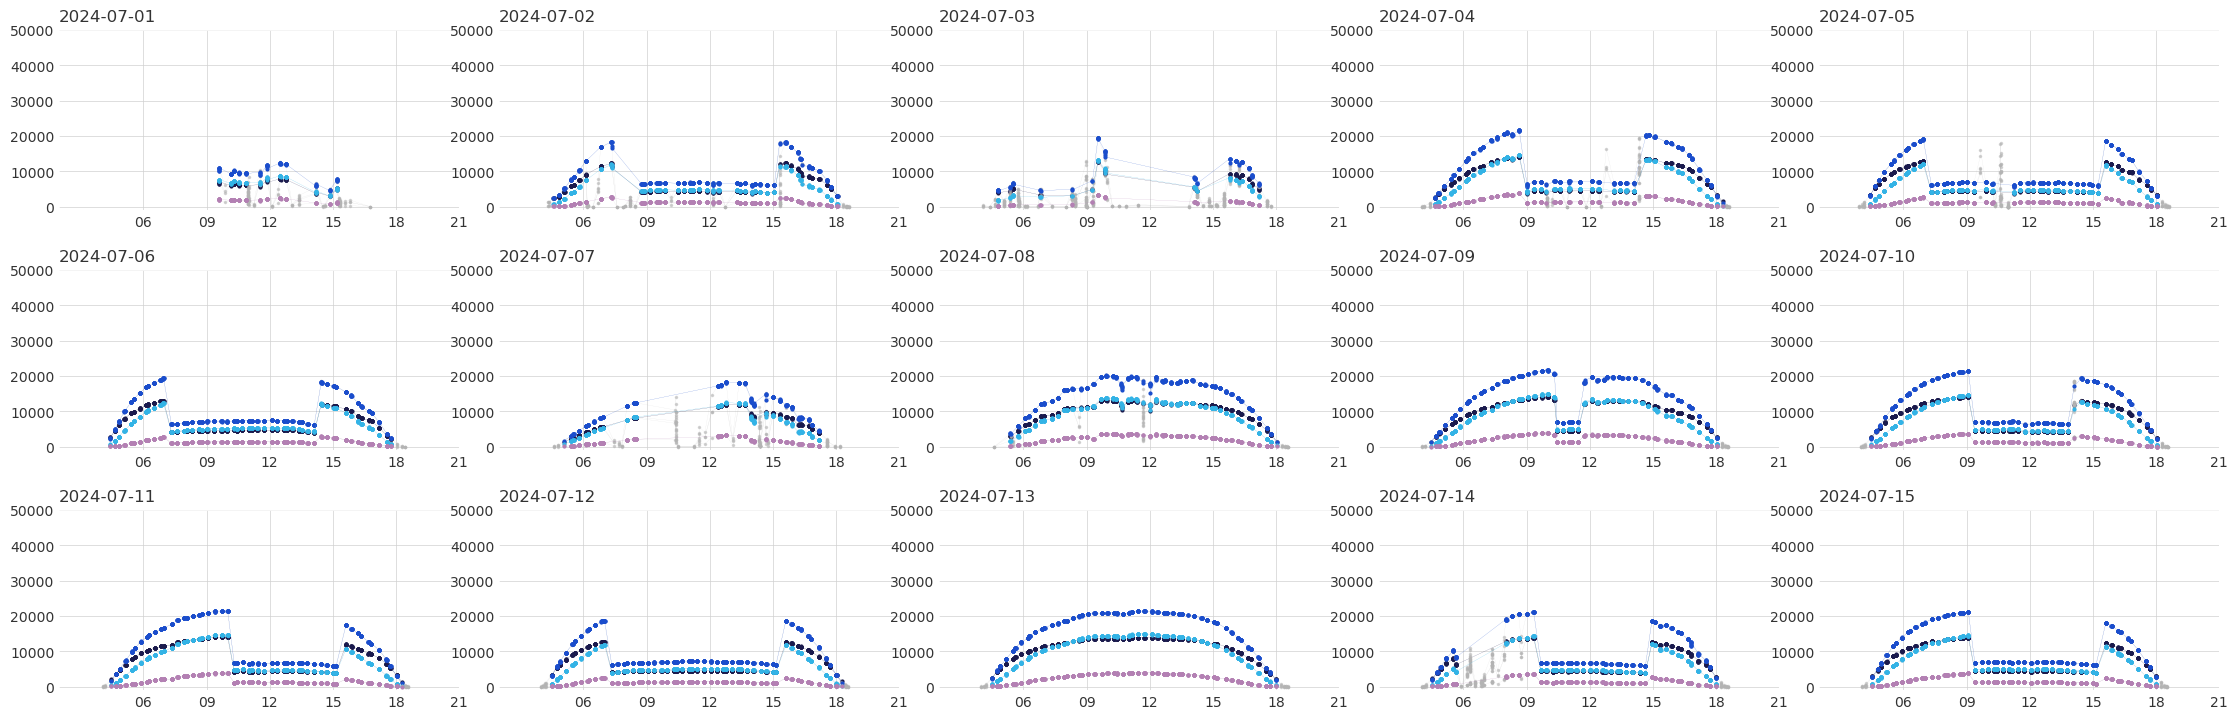

In [51]:
# plot first 2 weeks in July 2024

mask = (df_l0_all_corrected_filtered_norm.index >= '2024-07-01') & (df_l0_all_corrected_filtered_norm.index <= '2024-07-16')
fig = plot_pixel_timeseries(df_l0_all_corrected_filtered_norm[mask])

# save figure in plots folder
fig.savefig('../plots/pixel_timeseries_norm.png',bbox_inches='tight',dpi=300)

In [384]:
df_l0_all_corrected_filtered_norm.head()

,routine_code,integration_time,routine_count,repetition_count,filterwheel_pos1,filterwheel_pos2,aux_spec_temp,head_sens_temp,elec_temp1,data,date
time,,,,,,,,,,,
2024-01-01 07:31:22.400,SQ,238.93,264,1,1,2,27.93,18.71,20.87,"[0.2021596044950172, 0.21871012537735066, 0.16...",20240101
2024-01-01 07:44:50.800,SQ,81.75,267,1,1,2,27.93,19.17,20.87,"[0.46124034677447334, 0.40589150516153644, 0.4...",20240101
2024-01-01 07:53:19.000,SQ,25.43,270,1,2,2,28.05,19.54,20.77,"[0.9644505273068771, 1.1368258816238794, 0.934...",20240101
2024-01-01 07:53:34.300,SQ,25.43,270,2,2,2,28.11,19.65,20.77,"[0.7972377766710977, 0.9283337927985685, 0.786...",20240101
2024-01-01 07:53:49.700,SQ,25.43,270,3,2,2,28.11,19.65,20.77,"[0.3935244522455331, 0.5098129900376734, 0.362...",20240101


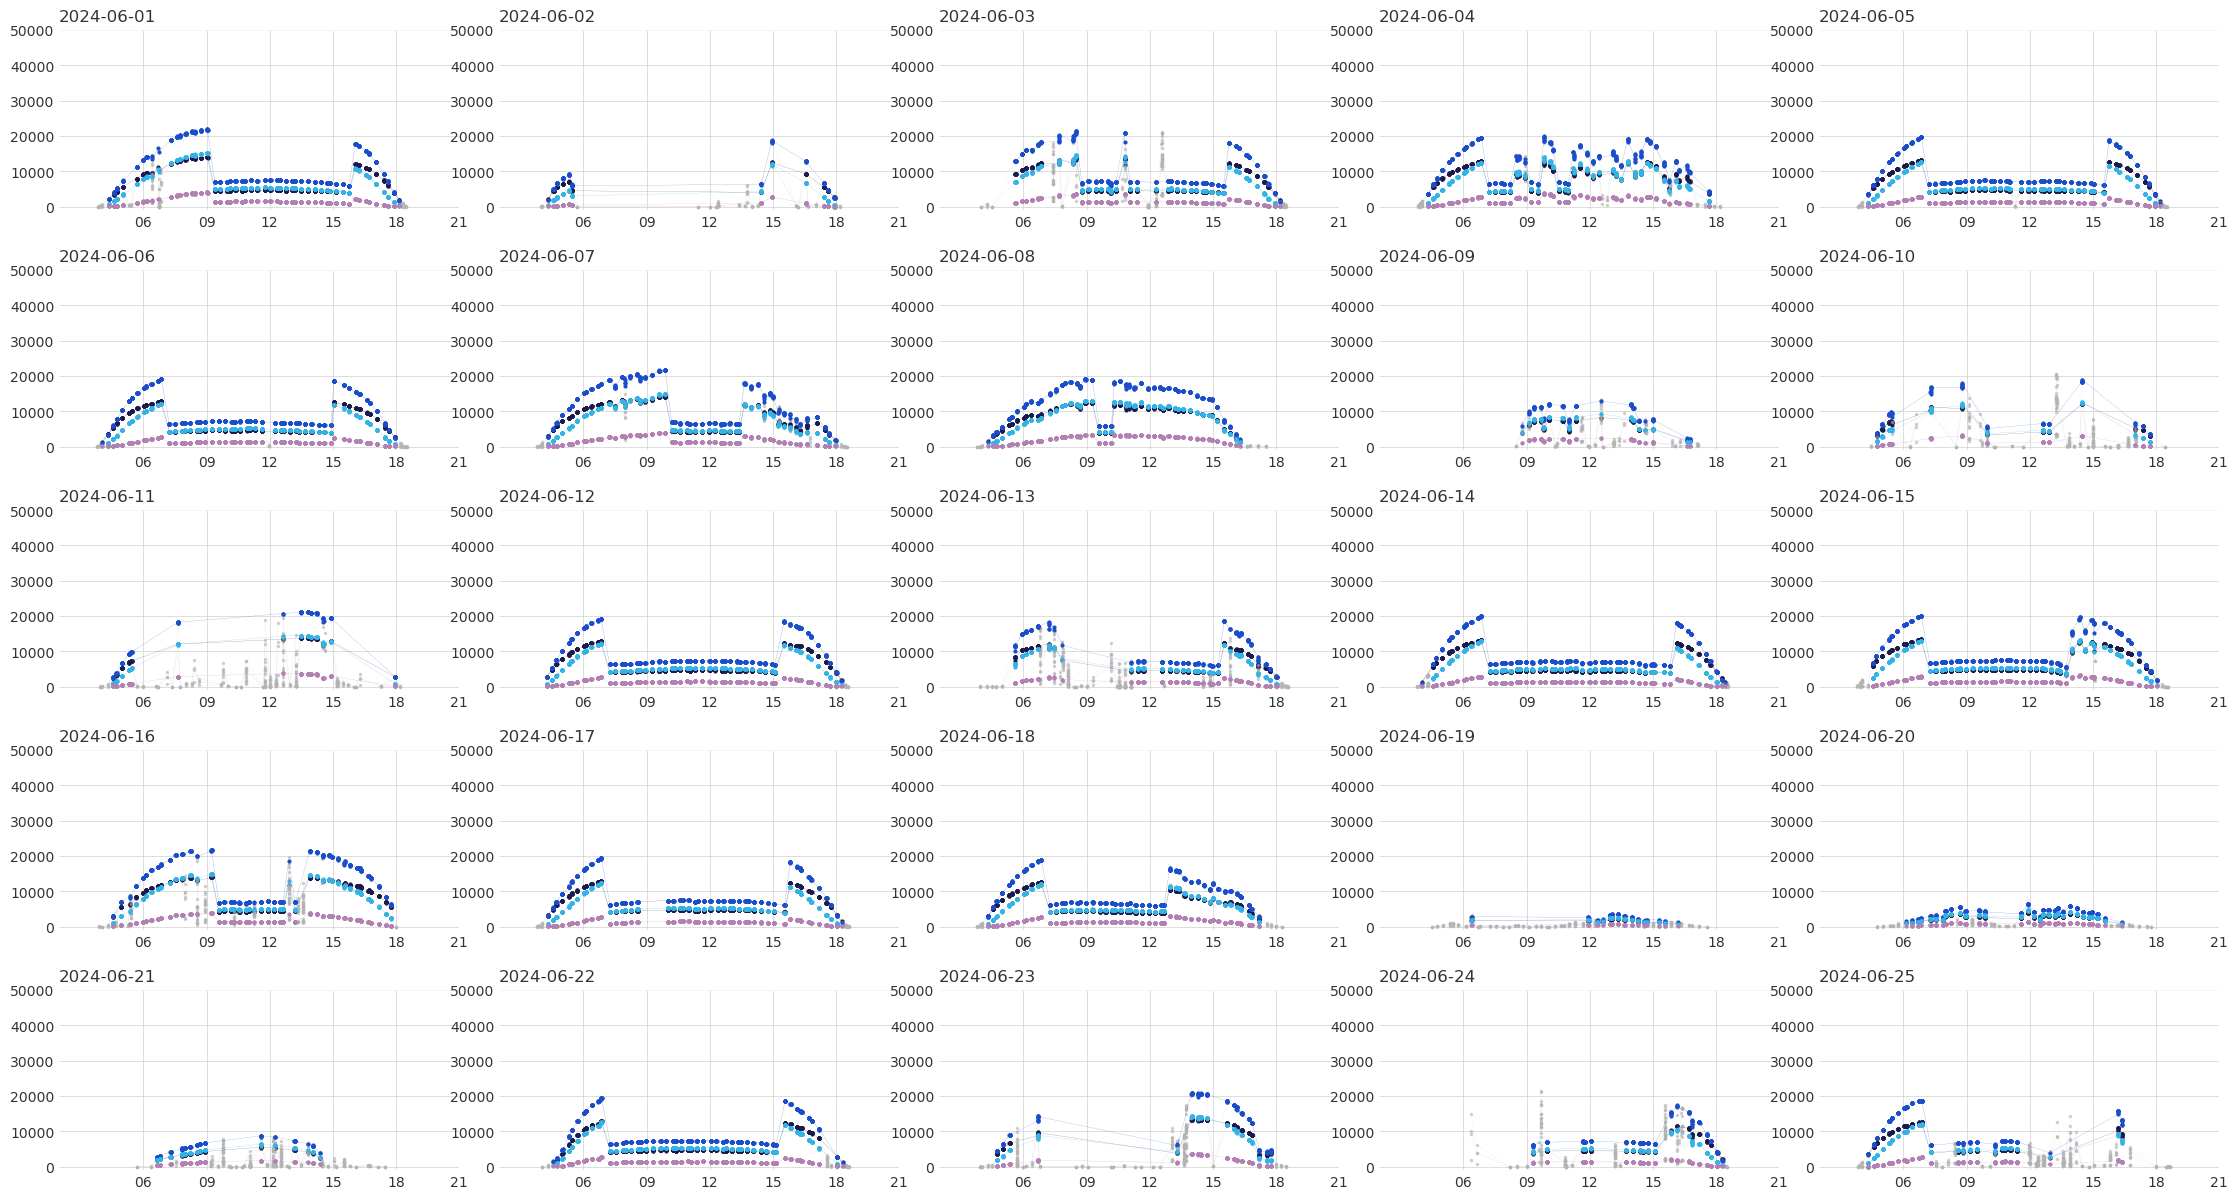

In [389]:
mask = (df_l0_all_corrected_filtered_norm.index >= '2024-06-01') & (df_l0_all_corrected_filtered_norm.index <= '2024-06-26')
fig = plot_pixel_timeseries(df_l0_all_corrected_filtered_norm.loc[mask],ncols=5)

#save figure
fig.savefig('../plots/spectra_20240601_20240626.png',bbox_inches='tight',dpi = 300)



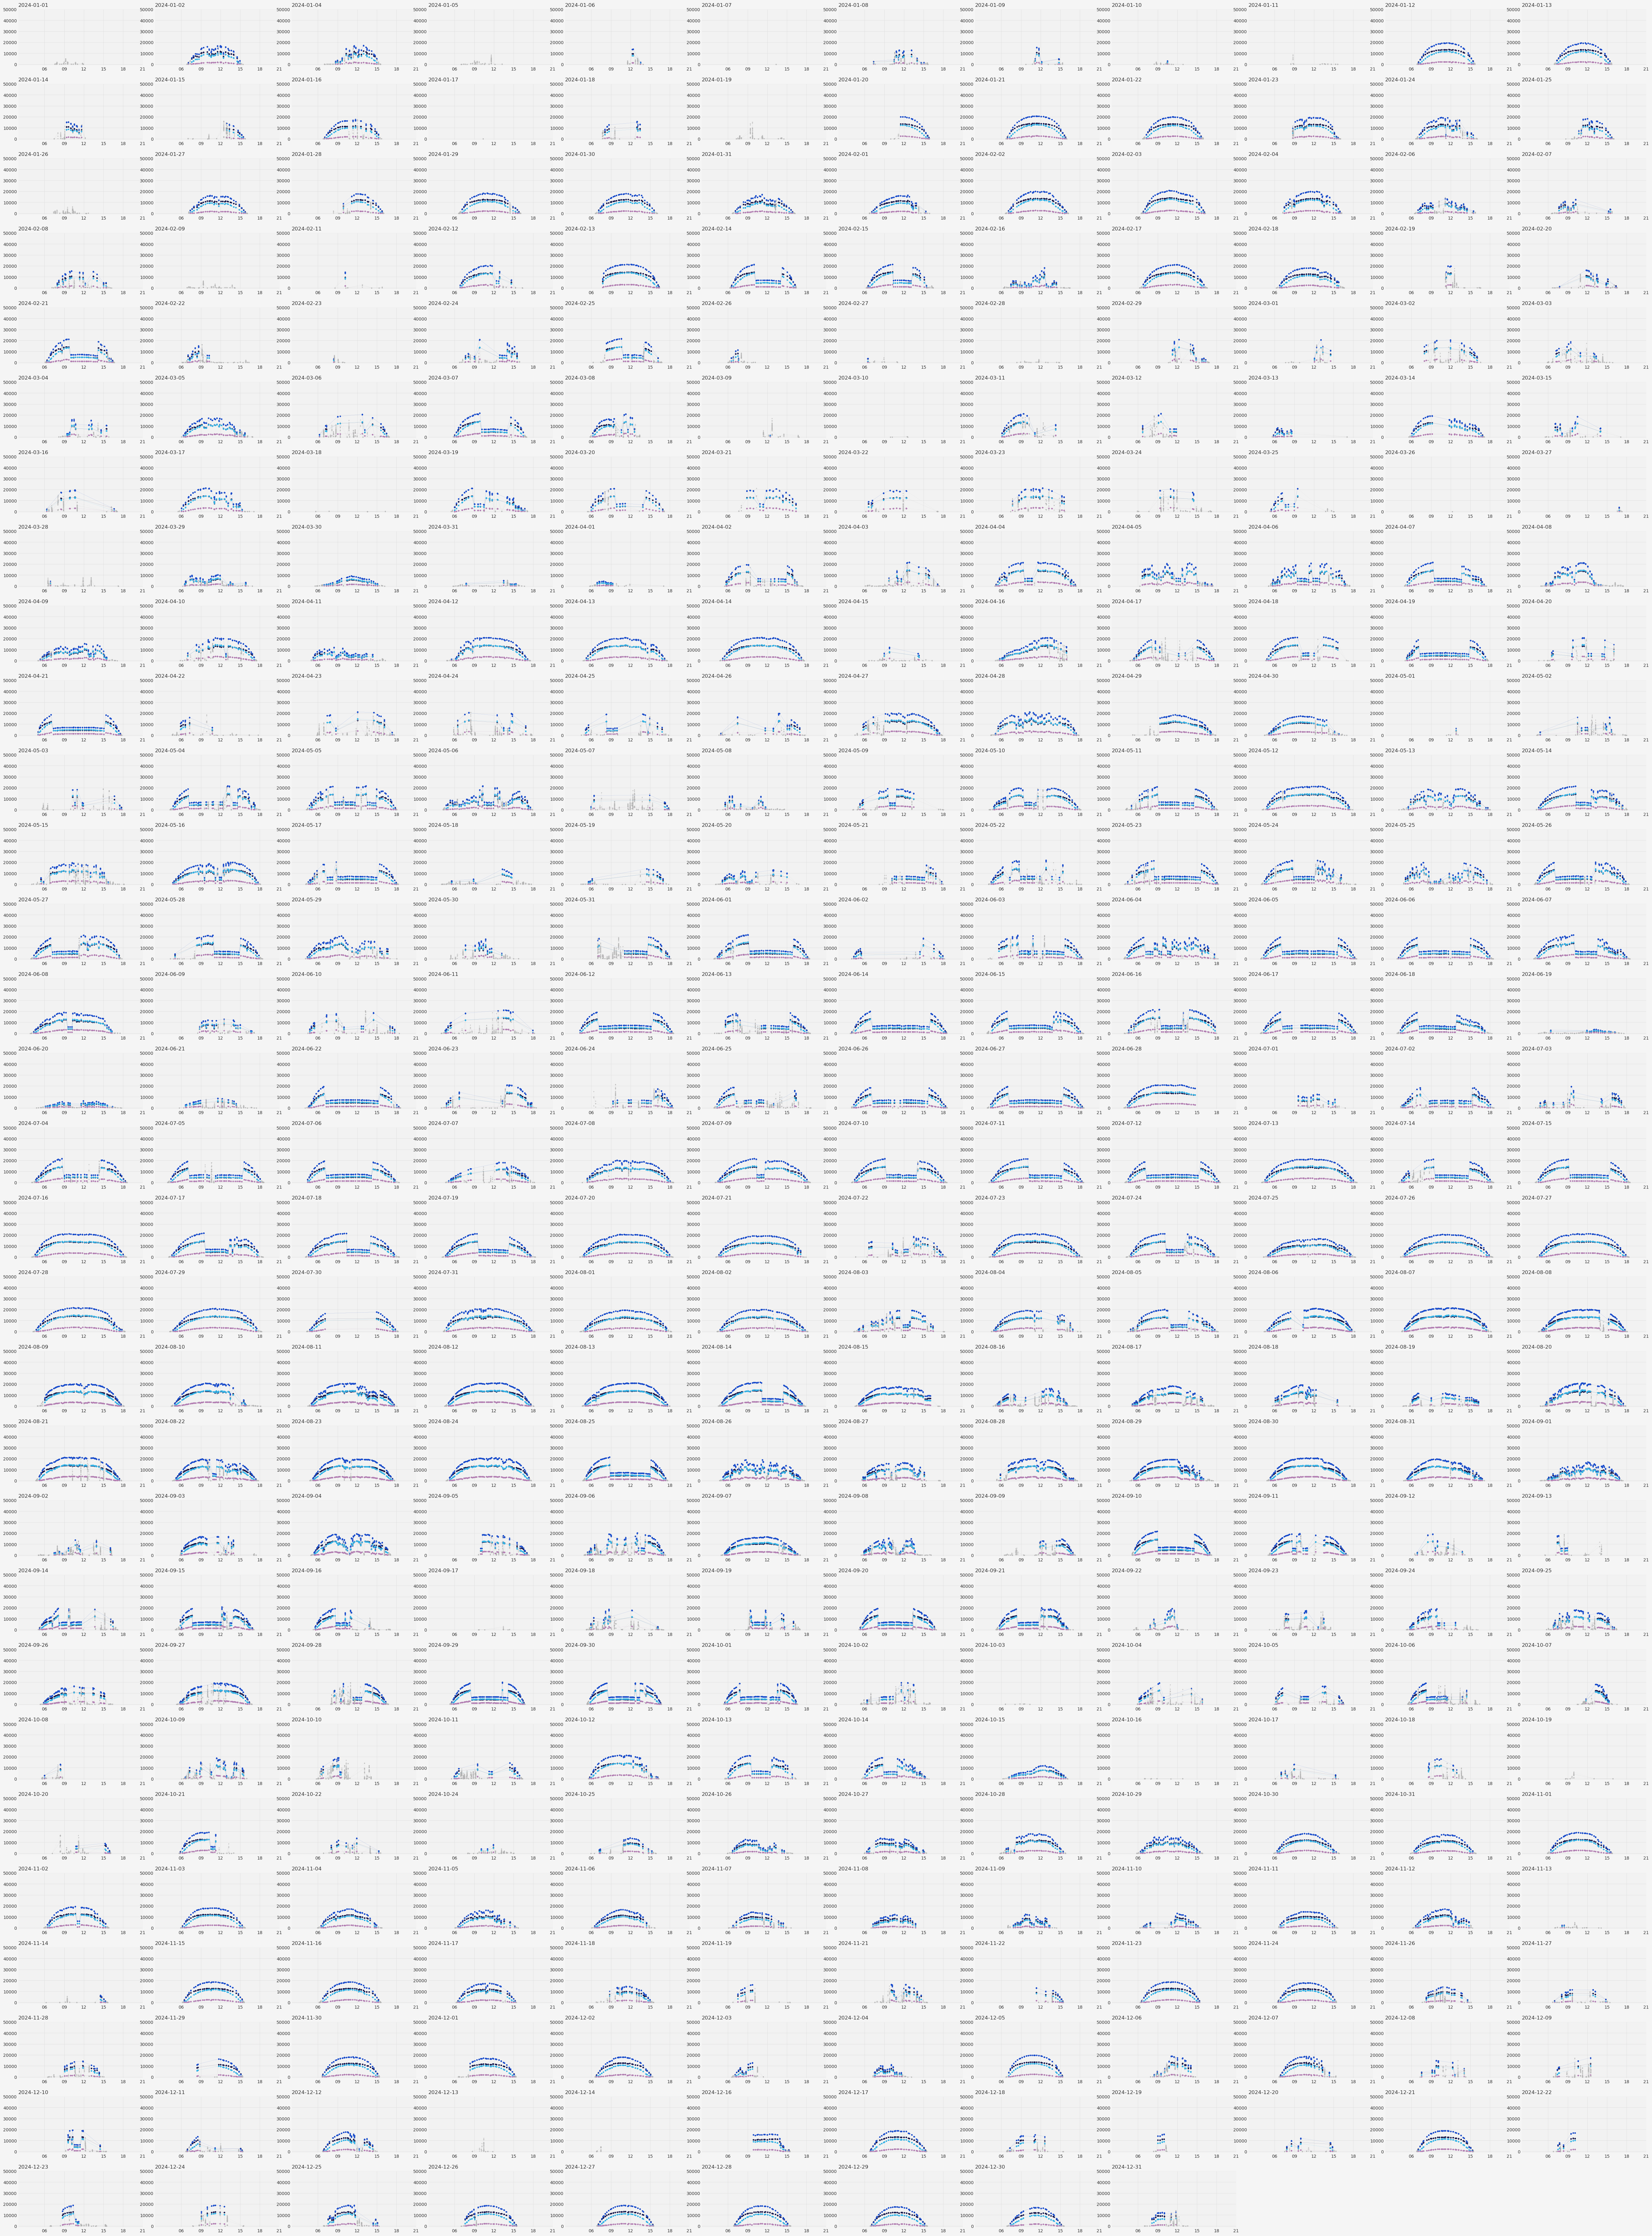

In [348]:
fig = plot_pixel_timeseries(df_l0_all_corrected_filtered_norm,ncols=12)

In [303]:
ind = df_l0_all_corrected_filtered_norm.index.date == pd.Timestamp('2024-07-12').date()

ind_c = dl0.cloudscreen_df(df_l0_all_corrected_filtered_norm, time_window='380s',lim=5e-3)
df_l0_all_corrected_filtered_norm_screened = df_l0_all_corrected_filtered_norm[ind_c]
df_l0_all_corrected_filtered_norm[ind_c]

,routine_code,integration_time,routine_count,repetition_count,filterwheel_pos1,filterwheel_pos2,aux_spec_temp,head_sens_temp,elec_temp1,data,date
time,,,,,,,,,,,
2024-07-01 09:35:58.300,SQ,4.19,3,3,2,2,20.77,40.39,23.32,"[147.0905512860041, 146.09840396173772, 146.09...",20240701
2024-07-01 09:36:04.400,SQ,4.19,3,4,2,2,20.77,40.39,23.32,"[147.07132878844976, 146.1052555450244, 145.99...",20240701
2024-07-01 09:36:10.600,SQ,4.19,3,5,2,2,20.77,40.39,23.32,"[147.43179819803356, 146.53538271802307, 146.2...",20240701
2024-07-01 10:09:13.400,SQ,4.92,15,3,2,2,20.89,41.57,23.64,"[124.89790130459444, 124.10228776706373, 123.9...",20240701
2024-07-01 10:09:19.400,SQ,4.92,15,4,2,2,20.89,41.57,23.64,"[125.14653053507278, 124.4936660994517, 124.22...",20240701
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 09:07:18.400,SQ,3.97,104,6,2,2,30.33,16.97,20.35,"[151.05195166471682, 150.0969830460679, 149.74...",20241231
2024-12-31 09:07:24.400,SQ,3.97,104,7,2,2,30.33,16.97,20.35,"[151.087772514738, 150.234550353064, 149.90377...",20241231
2024-12-31 09:07:30.500,SQ,3.97,104,8,2,2,30.33,16.97,20.35,"[150.68612170705404, 149.63874291680798, 149.4...",20241231


In [304]:
len(df_l0_all_corrected_filtered_norm_screened)/len(df_l0_all_corrected_filtered_norm)

0.44289709491467383

In [12]:
def get_cloudscreen_stats(df, time_window='300s', pixel_idx=500, lim=0.02):
    """Get daily statistics of total and cloudscreened spectra"""
    # Get cloudscreen mask
    clean_mask = dl0.cloudscreen_df(df, time_window=time_window, pixel_idx=pixel_idx, lim=lim)
    
    # Group by date
    stats = pd.DataFrame({
        'total_spectra': df.groupby(df.index.date).size(),
        'clean_spectra': clean_mask[clean_mask].groupby(clean_mask[clean_mask].index.date).size()
    })
    
    # Fill NaN in clean_spectra with 0
    stats['clean_spectra'] = stats['clean_spectra'].fillna(0).astype(int)
    
    # Add percentage column
    stats['clean_percentage'] = (stats['clean_spectra'] / stats['total_spectra'] * 100).round(1)
    
    return stats

In [362]:
daily_stats = get_cloudscreen_stats(df_l0_all_corrected_filtered_norm, time_window='60s', lim=1e-1)
daily_stats

,total_spectra,clean_spectra,clean_percentage
2024-01-01,30,3,10.0
2024-01-02,285,221,77.5
2024-01-04,232,157,67.7
2024-01-05,34,3,8.8
2024-01-06,50,23,46.0
...,...,...,...
2024-12-27,322,250,77.6
2024-12-28,316,246,77.8
2024-12-29,310,241,77.7
2024-12-30,280,216,77.1


In [380]:
len(df_l0_all_corrected_filtered_norm)

109241

In [13]:
def plot_cloudscreen_stats(stats_df):
    """
    Plot (cloudscreen) statistics of L0 spectra per day 
    as stacked bars
    """

    fig = plt.figure(figsize=(12,6))
    ax1 = fig.add_axes([0,.44,.9,.2])
    ax2 = fig.add_axes([0,.0,.9,.4])

    # xlims = from 1.1.2024 to 31.12.2024
    xlims = [pd.Timestamp('2023-12-27'), pd.Timestamp('2025-1-3')]

    ax1.plot(stats_df['total_spectra'].cumsum(), color=(.1,.4,.9), label='cloudy')
    #ax1.plot(stats_df['clean_spectra'].cumsum(), color=(.1,.3,.8), label='clean')

    # Plot total spectra bars
    ax2.bar(stats_df.index, stats_df['total_spectra'], color=(.1,.4,.9), 
           width=.8, label='cloudy',lw=0)
    
    ## Plot clean spectra bars
    #ax2.bar(stats_df.index, stats_df['clean_spectra']*1.3, color=(.1,.3,.8), 
    #       width=0.8, alpha=0.6, label='clean')
    
    
    #ax1 needs no xlabels
    ax1.set_xticklabels([])
    ax1.set_xlim(xlims)
    #('Cumulative number of spectra')
    ax1.annotate('cumulative number of spectra', xy=(0,1.05), xycoords='axes fraction', ha='left', fontsize=12)  
    ax1.grid(True)
    
    ax2.xaxis.set_major_locator(mdates.MonthLocator())
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax2.set_xlim(xlims)

    #x.set_xlabel('Date')
    ax2.set_ylabel('Number of Spectra')
    #ax2.legend()
    ax2.grid(True, alpha=1)
        
    
    return fig



In [7]:
import locale
# Set locale to English
# for date tick labels
locale.setlocale(locale.LC_TIME, 'en_US')  # Use 'en_US' for Windows, 'en_US.UTF-8' for most Unix/Linux systems

reload(pu)
pu.set_mpl_style(theme='white')

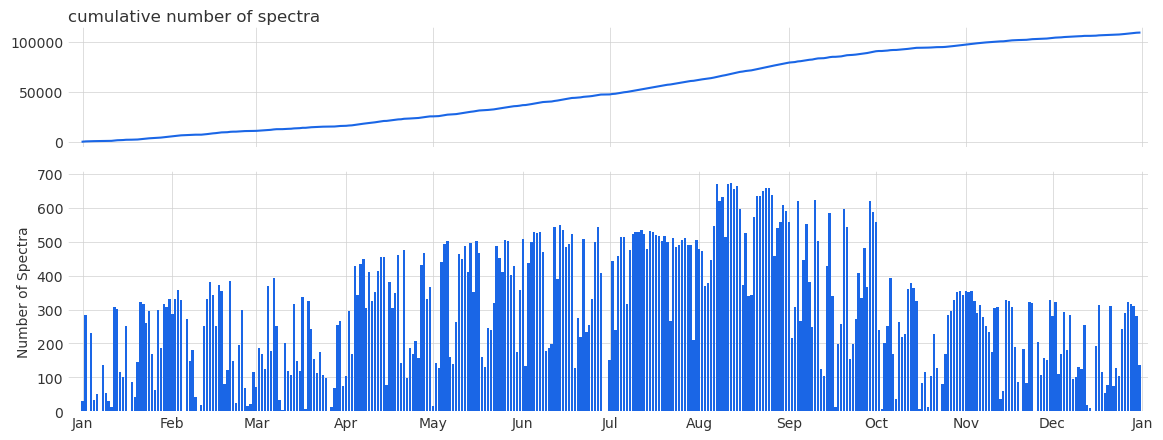

In [379]:
fig = plot_cloudscreen_stats(daily_stats)

#save figure in plots folder
fig.savefig('../plots/cloudscreen_stats_Rome-SAP.png',bbox_inches='tight',dpi=600)

In [6]:
fname =  f'../data/l0_datasets/Pandora21s1_Bremen_20240101_20241231.pkl'
df_l0_all = pd.read_pickle(fname)

In [10]:
reload(dl0) 

fw_comb_closed = {"fw1": 6, "fw2": 3} # filterwheel positions for closed position

df_l0_all_corrected = dl0.apply_dark_correction(df_l0_all,fw_comb_closed)

# filter out dark measurements
df_l0_all_corrected_filtered = dl0.filter_dark_measurements(df_l0_all_corrected,fw_comb_closed)
df_l0_all_corrected_filtered.head()

,routine_code,integration_time,routine_count,repetition_count,filterwheel_pos1,filterwheel_pos2,aux_spec_temp,head_sens_temp,data,date
time,,,,,,,,,,
2024-01-08 10:47:21.300,SQ,1092.185,3,1,1,4,22.11,5.25,"[1923.04, 2111.28, 1954.04, 1930.36, 1877.32, ...",20240108
2024-01-08 10:47:52.500,SQ,1092.185,3,2,1,3,22.11,5.25,"[1880.6666666666667, 2086.222222222222, 1923.0...",20240108
2024-01-08 10:52:34.700,SQ,7.175,6,1,1,4,22.12,5.77,"[811.078335373317, 810.5287637698898, 807.7649...",20240108
2024-01-08 10:52:42.300,SQ,7.175,6,2,1,4,22.12,5.77,"[808.1236230110159, 806.7197062423501, 804.154...",20240108
2024-01-08 10:52:49.600,SQ,7.175,6,3,1,4,22.12,5.77,"[771.4516523867809, 769.8029375764994, 767.400...",20240108


In [11]:
# normalize by integration time
df_l0_all_corrected_filtered_norm = dl0.normalize_by_integration_time(df_l0_all_corrected_filtered)

In [14]:
# stats of number of spectra per day
daily_stats = get_cloudscreen_stats(df_l0_all_corrected_filtered_norm, time_window='60s', lim=1e-1)

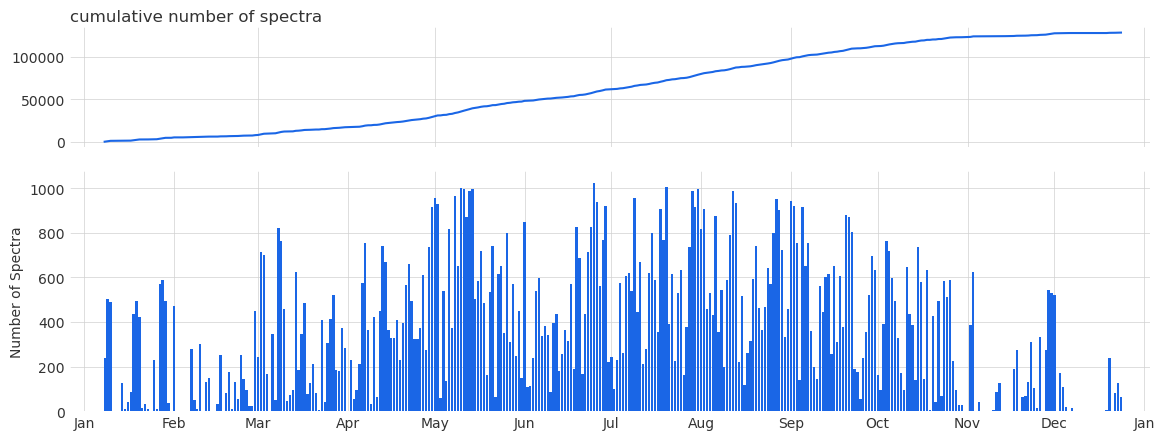

In [17]:
fig = plot_cloudscreen_stats(daily_stats)
fig.savefig('../plots/cloudscreen_stats_Bremen.png',bbox_inches='tight',dpi=600)
